In [1]:
import argparse
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
import torch
from utils import load_video_frames, load_vggt_model, unload_model, load_qwen_vl_model
from vggt_predict import vggt_predict
from object_discover import object_discover
import cv2
import numpy as np
import json

/home/xc/anaconda3/envs/ReplicateAnyScene/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
frames = load_video_frames('/home/xc/dmy_workspace/SimRecon_for_GALBOT/examples/hallway', 160).to('cuda')
print(f"Loaded {len(frames)} frames for processing.")
vggt_model = load_vggt_model().to('cuda')
vggt_prediction_results = vggt_predict(frames, vggt_model, 20)
# save colors, depths, intrinsics and sampled frames. Other attributes will be saved after we align the scene to a room coordinate system
# os.makedirs(os.path.join(args.output_path, 'color'), exist_ok=True)
# os.makedirs(os.path.join(args.output_path, 'depth'), exist_ok=True)
# os.makedirs(os.path.join(args.output_path, 'sampled_images'), exist_ok=True)
# for i, image in enumerate(vggt_prediction_results['colors']):
#     cv2.imwrite(os.path.join(args.output_path, 'color', f"{i}.jpg"), cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
#     if i in vggt_prediction_results['sa_ids']:
#         cv2.imwrite(os.path.join(args.output_path, 'sampled_images', f"{i}.jpg"), cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
# for i, depth in enumerate(vggt_prediction_results['depths']):
#     cv2.imwrite(os.path.join(args.output_path, 'depth', f"{i}.png"), (depth * 1000).astype(np.uint16))
# np.savetxt(os.path.join(args.output_path, 'intrinsic.txt'), vggt_prediction_results['intrinsic'])
unload_model(vggt_model)

Loaded 160 frames for processing.
Loading weights from local directory


/home/xc/dmy_workspace/ReplicateAnyScene/vggt_predict.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=dtype):
/home/xc/dmy_workspace/ReplicateAnyScene/vggt/vggt/models/vggt.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


In [3]:
from utils import load_sam3_image_model
from object_segmeantation import segment_wall_and_floor
sam3_image_model = load_sam3_image_model()
wall_masks, floor_masks = segment_wall_and_floor(vggt_prediction_results['colors'], sam3_image_model)

In [4]:
vggt_prediction_results['colors'].shape

(160, 392, 518, 3)

In [5]:
vggt_prediction_results['world_points'][0].shape
wall_masks[0]['mask'].shape

(392, 518)

In [6]:
from utils import get_plane_info
result = get_plane_info(vggt_prediction_results['world_points'][0], wall_masks[0]['mask'])
print(result['normal'].shape)
print(result['normal'])
M = np.array([list(result['normal']), list(result['normal']), list(result['normal'])]).T
print(M)
M = np.stack([result['normal'], result['normal'], result['normal']], axis=1)
print(M)

(3,)
[ 0.98903637 -0.1282335   0.07323406]
[[ 0.98903637  0.98903637  0.98903637]
 [-0.1282335  -0.1282335  -0.1282335 ]
 [ 0.07323406  0.07323406  0.07323406]]
[[ 0.98903637  0.98903637  0.98903637]
 [-0.1282335  -0.1282335  -0.1282335 ]
 [ 0.07323406  0.07323406  0.07323406]]


In [7]:
from utils import align_to_room_coordinate_system
R, t = align_to_room_coordinate_system(vggt_prediction_results['world_points'], wall_masks, floor_masks)
print("Rotation matrix R:")
print(R)
print("Translation vector t:")
print(t)

Rotation matrix R:
[[ 0.92528312  0.37912166  0.010859  ]
 [-0.17422166  0.39942488  0.90005921]
 [ 0.33689459 -0.83470147  0.4356323 ]]
Translation vector t:
[-0.07253276 -0.33741306 -0.58254298]


In [ ]:
import trimesh
pcd = vggt_prediction_results['point_cloud_data']
pcd = pcd.apply_transform(np.vstack([np.hstack([R, t.reshape(3, 1)]), [0, 0, 0, 1]]))
pcd.export('/home/xc/dmy_workspace/ReplicateAnyScene/results/aligned_point_cloud.ply')

<class 'str'>


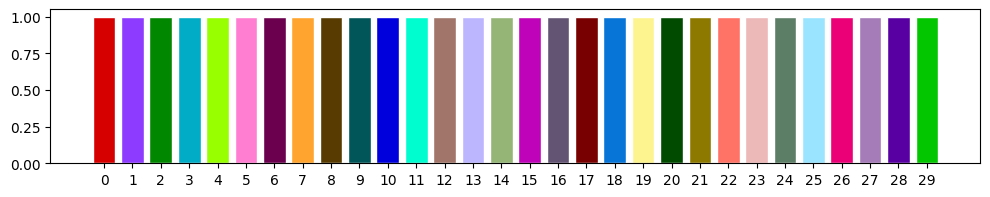

In [ ]:
import colorcet as cc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# cc.glasbey 提供适合分类数据的高区分度颜色
# 取前 N 个（超过一定数量后会循环，建议 N <= 256）
def get_glasbey_colors(n):
    hex_colors = cc.glasbey[:n]
    bgr_colors = []
    for hex_val in hex_colors:
        rgb_float = mcolors.to_rgb(hex_val)
        r, g, b = tuple(int(x * 255) for x in rgb_float)
        bgr_colors.append((b, g, r))
    return bgr_colors


colors = get_glasbey_colors(30)
print(type(colors[0]))
plt.figure(figsize=(12, 2))
for i, color in enumerate(colors):
    plt.bar(i, 1, color=color, edgecolor='white')
plt.xticks(range(len(colors)))
plt.show()